# Heterogeneous Graph-KAN for Wind Farm Forecasting
## Project Setup and Exploratory Data Analysis

**Goal**: Build a novel deep learning framework combining Kolmogorov-Arnold Networks (KAN) with heterogeneous graph neural networks for wind power forecasting.

**Dataset**: Wind Spatio-Temporal Dataset2.csv
- 200 wind turbines + 3 meteorological masts
- 8,764 hourly timestamps (Sept 2010 - Aug 2011)
- 606 features total

**Novel Contribution**: Replace traditional MLP-based graph convolutions with interpretable KAN layers for adaptive spatio-temporal transformations.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.1.3
Pandas version: 2.3.2


## 2. Load and Parse Wind Dataset

The dataset has a special structure:
- **Row 1**: Column headers (Turbine1, Turbine2, ..., Mast1, Mast2, Mast3)
- **Row 2**: Latitude coordinates
- **Row 3**: Longitude coordinates
- **Row 4**: Empty separator
- **Row 5+**: Time series data with Time column + Speed/Power columns

In [8]:
# Define data path - dataset is in data/raw folder
data_path = Path("../data/raw/Wind Spatio-Temporal Dataset2.csv")

# Read first 3 rows to get coordinates
coords_df = pd.read_csv(data_path, nrows=3, header=None)

# Read actual time series data
# Skip first 4 rows (header + 2 coord rows + empty row), row 5 has column names
df = pd.read_csv(data_path, skiprows=4)

# Rename first column from "Unnamed: 0" to "Time"
df = df.rename(columns={df.columns[0]: 'Time'})

print(f"Coordinate data shape: {coords_df.shape}")
print(f"Time series data shape: {df.shape}")
print(f"\nFirst few column names: {list(df.columns[:10])}")
print(f"Last few column names: {list(df.columns[-6:])}")
print(f"\nFirst few rows of Time column:")
print(df['Time'].head())

Coordinate data shape: (3, 407)
Time series data shape: (8760, 407)

First few column names: ['Time', 'Turbine1_Speed', 'Turbine1_Power', 'Turbine2_Speed', 'Turbine2_Power', 'Turbine3_Speed', 'Turbine3_Power', 'Turbine4_Speed', 'Turbine4_Power', 'Turbine5_Speed']
Last few column names: ['Mast1_Speed', 'Mast1_Direction', 'Mast2_Speed', 'Mast2_Direction', 'Mast3_Speed', 'Mast3_Direction']

First few rows of Time column:
0    9/1/2010 0:00
1    9/1/2010 1:00
2    9/1/2010 2:00
3    9/1/2010 3:00
4    9/1/2010 4:00
Name: Time, dtype: object


## 3. Extract Coordinates and Create Node Metadata

In [4]:
def extract_node_metadata(coords_df: pd.DataFrame) -> pd.DataFrame:
    """Extract latitude, longitude, and node metadata from coordinate rows."""
    
    # First row is headers, second is latitudes, third is longitudes
    headers = coords_df.iloc[0, 1:].values  # Skip first column (empty or index)
    latitudes = coords_df.iloc[1, 1:].values
    longitudes = coords_df.iloc[2, 1:].values
    
    # Create metadata dataframe
    metadata = pd.DataFrame({
        'node_name': headers,
        'latitude': pd.to_numeric(latitudes, errors='coerce'),
        'longitude': pd.to_numeric(longitudes, errors='coerce')
    })
    
    # Determine node type
    metadata['node_type'] = metadata['node_name'].apply(
        lambda x: 'mast' if 'Mast' in str(x) else 'turbine'
    )
    
    # Assign node IDs
    metadata['node_id'] = range(len(metadata))
    
    # Remove rows with NaN coordinates
    metadata = metadata.dropna(subset=['latitude', 'longitude'])
    
    return metadata

# Extract metadata
node_metadata = extract_node_metadata(coords_df)

print(f"Total nodes: {len(node_metadata)}")
print(f"Turbines: {len(node_metadata[node_metadata['node_type'] == 'turbine'])}")
print(f"Masts: {len(node_metadata[node_metadata['node_type'] == 'mast'])}")
print(f"\nMetadata sample:")
print(node_metadata.head())

Total nodes: 203
Turbines: 200
Masts: 3

Metadata sample:
  node_name   latitude  longitude node_type  node_id
0  Turbine1  40.477244 -88.798072   turbine        0
1  Turbine2  40.475753 -88.795484   turbine        1
2  Turbine3  40.482172 -88.779434   turbine        2
3  Turbine4  40.476083 -88.779391   turbine        3
4  Turbine5  40.477691 -88.772025   turbine        4


### Visualize Wind Farm Spatial Layout

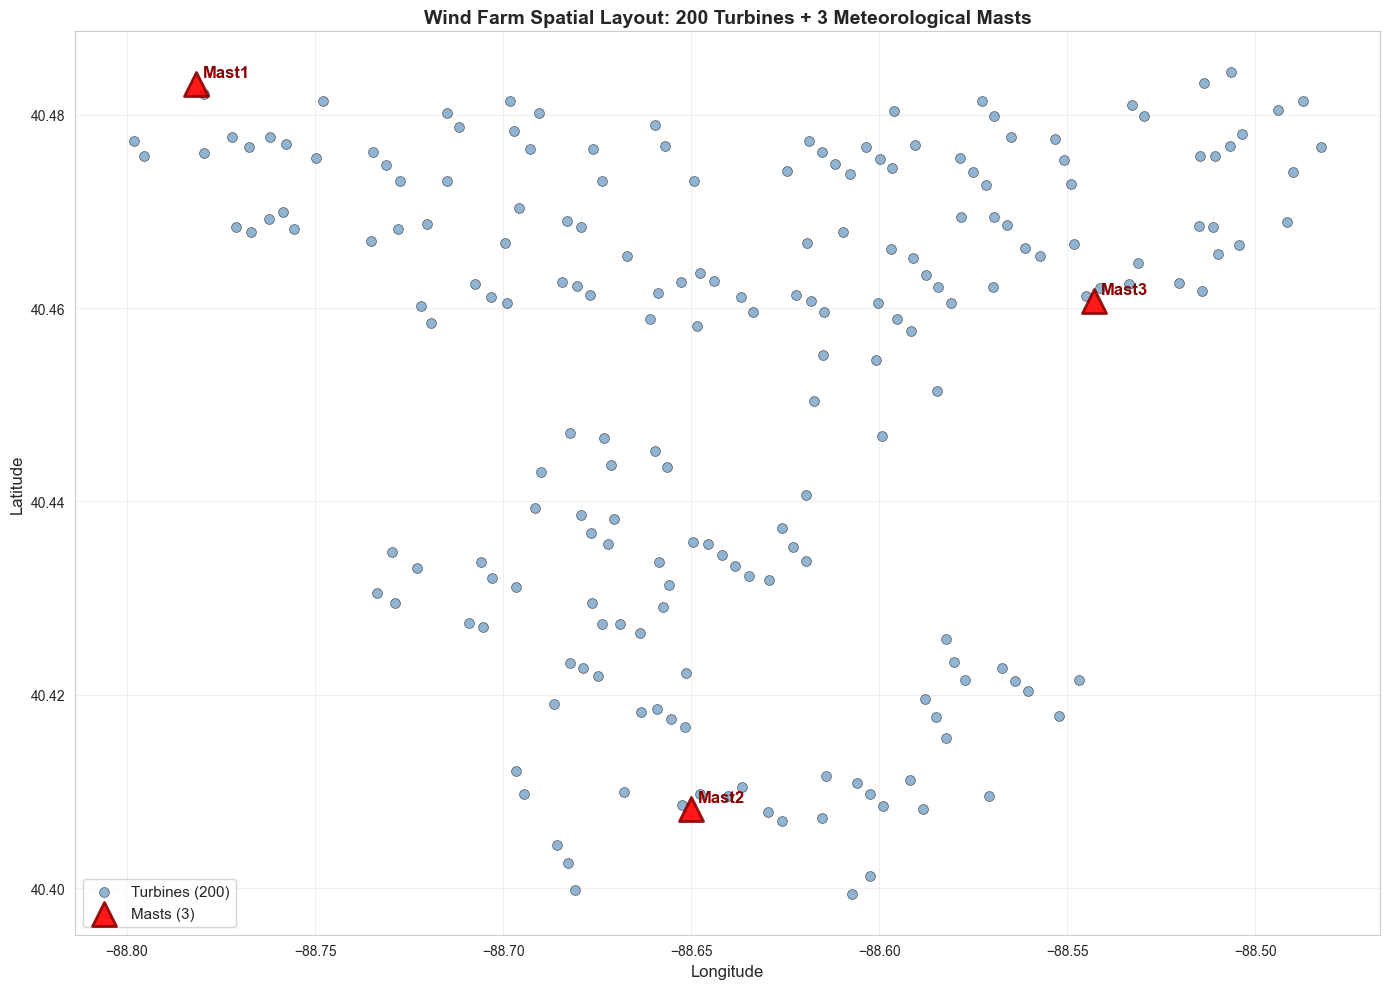

Latitude range: 40.399432 to 40.484373
Longitude range: -88.798072 to -88.482632


In [5]:
plt.figure(figsize=(14, 10))

# Plot turbines
turbines = node_metadata[node_metadata['node_type'] == 'turbine']
masts = node_metadata[node_metadata['node_type'] == 'mast']

plt.scatter(turbines['longitude'], turbines['latitude'], 
           c='steelblue', s=50, alpha=0.6, label='Turbines (200)', edgecolors='k', linewidths=0.5)
plt.scatter(masts['longitude'], masts['latitude'], 
           c='red', s=300, alpha=0.9, marker='^', label='Masts (3)', edgecolors='darkred', linewidths=2)

# Add labels for masts
for idx, row in masts.iterrows():
    plt.annotate(row['node_name'], 
                xy=(row['longitude'], row['latitude']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=12, fontweight='bold', color='darkred')

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('Wind Farm Spatial Layout: 200 Turbines + 3 Meteorological Masts', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Latitude range: {turbines['latitude'].min():.6f} to {turbines['latitude'].max():.6f}")
print(f"Longitude range: {turbines['longitude'].min():.6f} to {turbines['longitude'].max():.6f}")

## 4. Analyze Time Series Data Structure

In [9]:
# Convert Time column to datetime
df['Time'] = pd.to_datetime(df['Time'], format='%m/%d/%Y %H:%M')
df = df.sort_values('Time').reset_index(drop=True)

print(f"Time range: {df['Time'].min()} to {df['Time'].max()}")
print(f"Total timestamps: {len(df)}")
print(f"Time resolution: {(df['Time'].iloc[1] - df['Time'].iloc[0])}")

# Identify Speed and Power columns
speed_cols = [col for col in df.columns if 'Speed' in col]
power_cols = [col for col in df.columns if 'Power' in col]
direction_cols = [col for col in df.columns if 'Direction' in col]

print(f"\nSpeed columns: {len(speed_cols)}")
print(f"Power columns: {len(power_cols)}")
print(f"Direction columns: {len(direction_cols)}")

# Check for missing values
print(f"\nMissing values in power columns: {df[power_cols].isna().sum().sum()}")
print(f"Missing values percentage: {df[power_cols].isna().sum().sum() / (len(df) * len(power_cols)) * 100:.2f}%")

Time range: 2010-09-01 00:00:00 to 2011-08-31 22:59:00
Total timestamps: 8760
Time resolution: 0 days 01:00:00

Speed columns: 203
Power columns: 200
Direction columns: 3

Missing values in power columns: 354560
Missing values percentage: 20.24%


### Visualize Sample Turbine Time Series

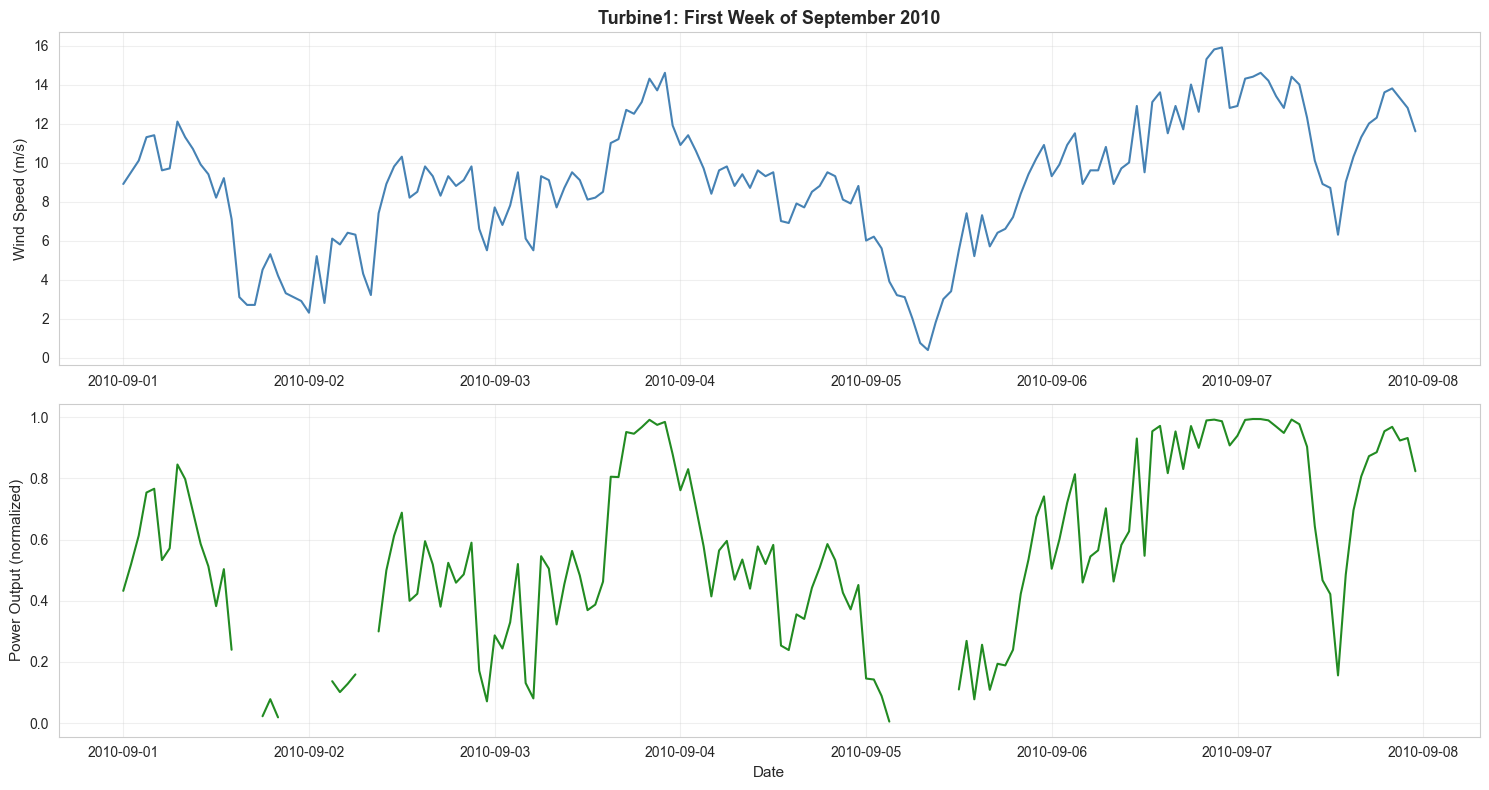

In [10]:
# Plot first week of data for a sample turbine
sample_turbine = 'Turbine1'
sample_data = df[['Time', f'{sample_turbine}_Speed', f'{sample_turbine}_Power']].head(168)  # 7 days * 24 hours

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Wind speed
axes[0].plot(sample_data['Time'], sample_data[f'{sample_turbine}_Speed'], 
            color='steelblue', linewidth=1.5)
axes[0].set_ylabel('Wind Speed (m/s)', fontsize=11)
axes[0].set_title(f'{sample_turbine}: First Week of September 2010', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Power output
axes[1].plot(sample_data['Time'], sample_data[f'{sample_turbine}_Power'], 
            color='forestgreen', linewidth=1.5)
axes[1].set_ylabel('Power Output (normalized)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Distribution Analysis

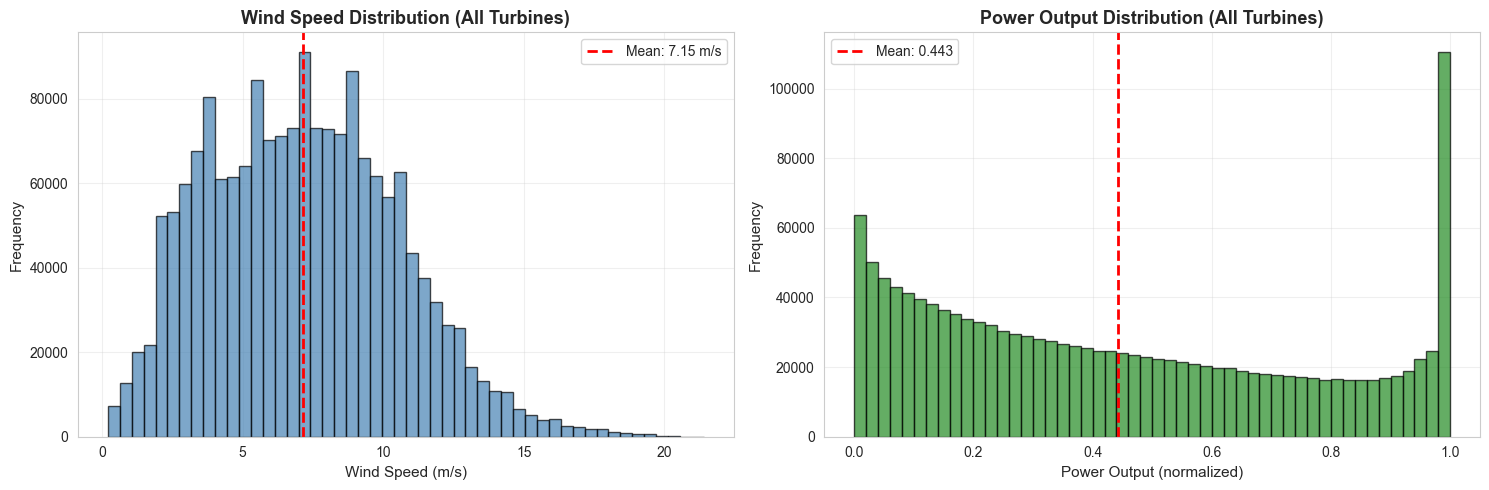

Wind Speed Stats: Mean=7.15, Std=3.38, Min=0.20, Max=21.40
Power Output Stats: Mean=0.443, Std=0.321, Min=0.000, Max=1.000


In [11]:
# Analyze distributions across all turbines
all_speeds = df[speed_cols[:200]].values.flatten()  # Turbine speeds only
all_powers = df[power_cols[:200]].values.flatten()  # Turbine powers only

# Remove NaN values
all_speeds = all_speeds[~np.isnan(all_speeds)]
all_powers = all_powers[~np.isnan(all_powers)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Wind speed distribution
axes[0].hist(all_speeds, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Wind Speed (m/s)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Wind Speed Distribution (All Turbines)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(np.mean(all_speeds), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_speeds):.2f} m/s')
axes[0].legend()

# Power output distribution
axes[1].hist(all_powers, bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Power Output (normalized)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Power Output Distribution (All Turbines)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(np.mean(all_powers), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_powers):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Wind Speed Stats: Mean={np.mean(all_speeds):.2f}, Std={np.std(all_speeds):.2f}, Min={np.min(all_speeds):.2f}, Max={np.max(all_speeds):.2f}")
print(f"Power Output Stats: Mean={np.mean(all_powers):.3f}, Std={np.std(all_powers):.3f}, Min={np.min(all_powers):.3f}, Max={np.max(all_powers):.3f}")

### Power Curve Analysis: Speed vs Power Relationship

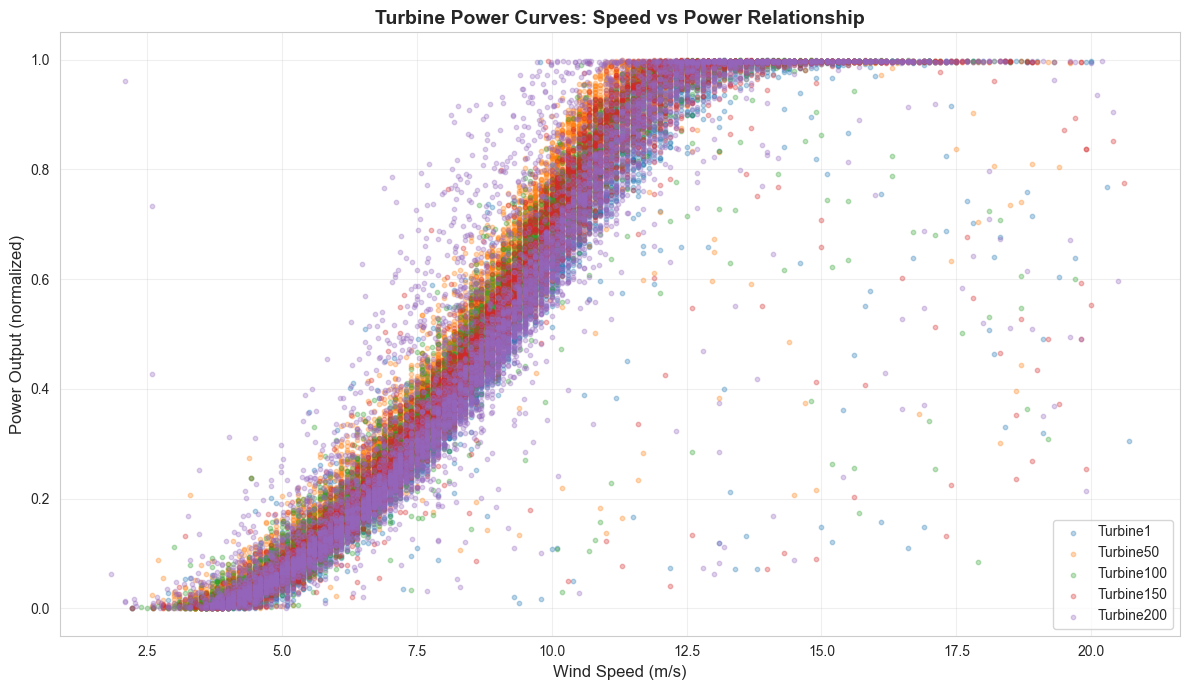

Note: Typical wind turbine power curve shows:
  - Cut-in speed (~3-4 m/s): turbine starts generating power
  - Rated speed (~12-15 m/s): maximum power output
  - Cut-out speed (~25 m/s): turbine stops for safety


In [12]:
# Sample 5 turbines for power curve visualization
sample_turbines = ['Turbine1', 'Turbine50', 'Turbine100', 'Turbine150', 'Turbine200']

plt.figure(figsize=(12, 7))

for turbine in sample_turbines:
    speed_col = f'{turbine}_Speed'
    power_col = f'{turbine}_Power'
    
    # Get data and remove NaNs
    data = df[[speed_col, power_col]].dropna()
    
    plt.scatter(data[speed_col], data[power_col], 
               alpha=0.3, s=10, label=turbine)

plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Power Output (normalized)', fontsize=12)
plt.title('Turbine Power Curves: Speed vs Power Relationship', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Note: Typical wind turbine power curve shows:")
print("  - Cut-in speed (~3-4 m/s): turbine starts generating power")
print("  - Rated speed (~12-15 m/s): maximum power output")
print("  - Cut-out speed (~25 m/s): turbine stops for safety")

## 6. Temporal Patterns Analysis

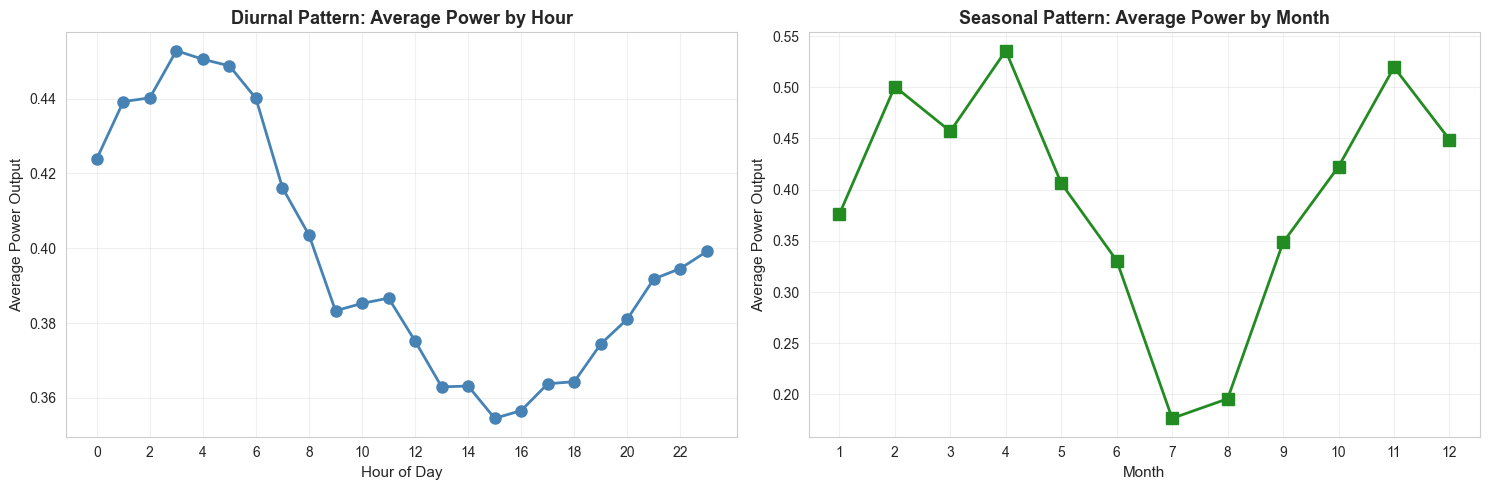

In [13]:
# Extract temporal features
df['hour'] = df['Time'].dt.hour
df['day_of_week'] = df['Time'].dt.dayofweek
df['month'] = df['Time'].dt.month
df['day_of_year'] = df['Time'].dt.dayofyear

# Compute average power across all turbines for each timestamp
df['avg_power'] = df[power_cols[:200]].mean(axis=1)

# Hourly patterns
hourly_avg = df.groupby('hour')['avg_power'].mean()

# Monthly patterns
monthly_avg = df.groupby('month')['avg_power'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hourly pattern
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Hour of Day', fontsize=11)
axes[0].set_ylabel('Average Power Output', fontsize=11)
axes[0].set_title('Diurnal Pattern: Average Power by Hour', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# Monthly pattern
axes[1].plot(monthly_avg.index, monthly_avg.values, marker='s', linewidth=2, markersize=8, color='forestgreen')
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Average Power Output', fontsize=11)
axes[1].set_title('Seasonal Pattern: Average Power by Month', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## 7. Spatial Correlation Analysis

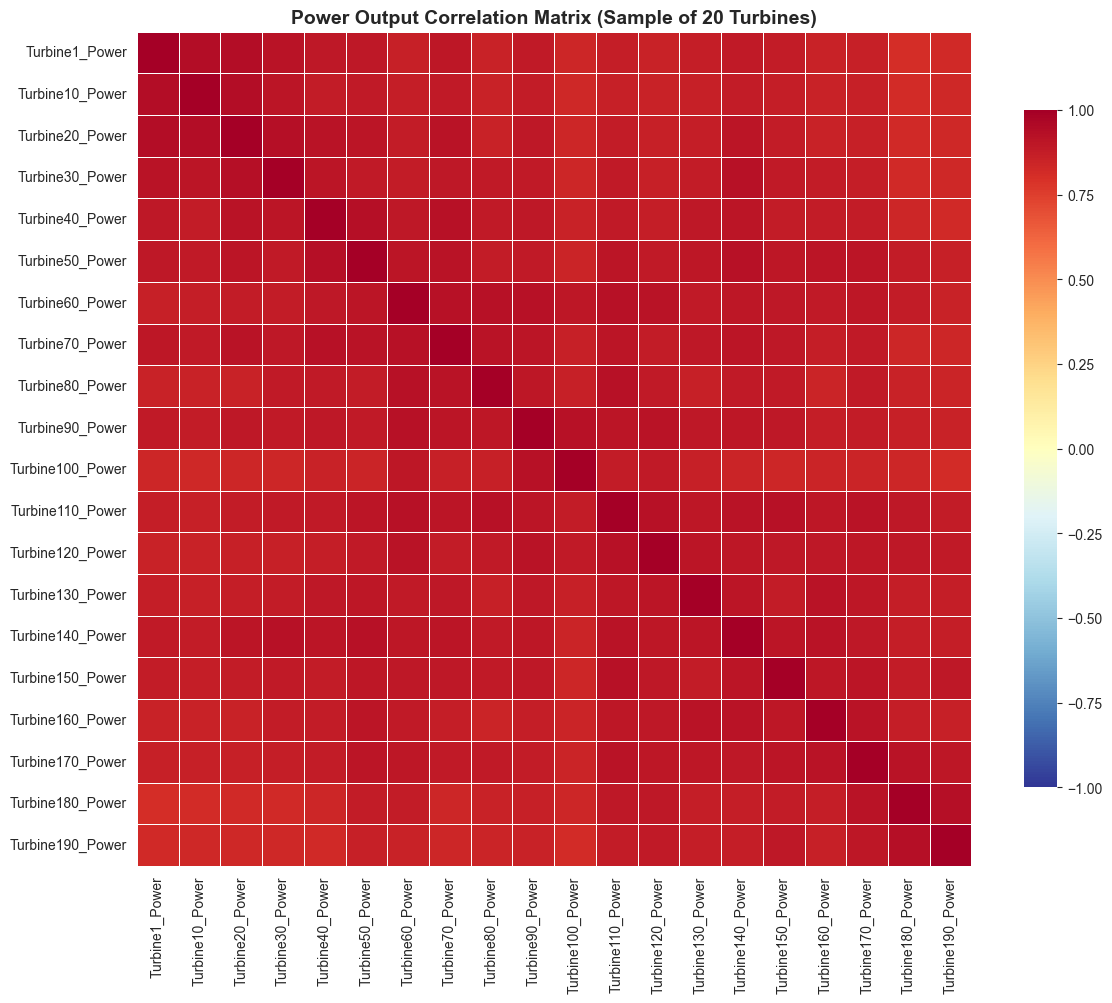


Highly correlated turbine pairs (correlation > 0.8):
  Turbine1_Power <-> Turbine10_Power: 0.945
  Turbine1_Power <-> Turbine20_Power: 0.938
  Turbine1_Power <-> Turbine30_Power: 0.914
  Turbine1_Power <-> Turbine40_Power: 0.895
  Turbine1_Power <-> Turbine50_Power: 0.893
  Turbine1_Power <-> Turbine60_Power: 0.866
  Turbine1_Power <-> Turbine70_Power: 0.900
  Turbine1_Power <-> Turbine80_Power: 0.854
  Turbine1_Power <-> Turbine90_Power: 0.889
  Turbine1_Power <-> Turbine100_Power: 0.840


In [14]:
# Sample 20 turbines for correlation analysis (full 200x200 would be too large to visualize)
sample_turbine_cols = [f'Turbine{i}_Power' for i in [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 
                                                        100, 110, 120, 130, 140, 150, 160, 170, 180, 190]]

# Compute correlation matrix
corr_matrix = df[sample_turbine_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Power Output Correlation Matrix (Sample of 20 Turbines)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_threshold = 0.8
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > high_corr_threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"\nHighly correlated turbine pairs (correlation > {high_corr_threshold}):")
for pair in high_corr_pairs[:10]:  # Show first 10
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.3f}")

## 8. Wind Direction Analysis (Masts)

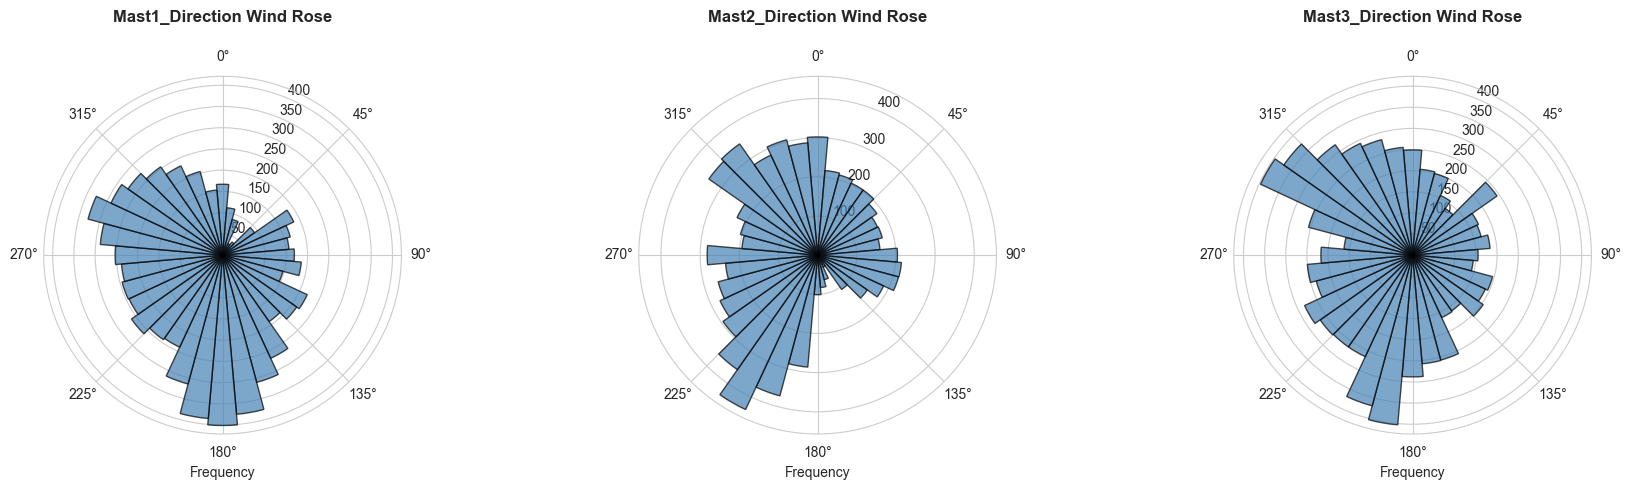

Mast1_Direction: Mean direction = 203.4°, Std = 90.6°
Mast2_Direction: Mean direction = 196.4°, Std = 107.4°
Mast3_Direction: Mean direction = 197.8°, Std = 102.5°


In [15]:
# Wind direction rose plot
mast_directions = []
for col in direction_cols:
    mast_directions.append(df[col].dropna().values)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw=dict(projection='polar'))

for idx, (directions, col) in enumerate(zip(mast_directions, direction_cols)):
    # Convert to radians
    directions_rad = np.deg2rad(directions)
    
    # Create histogram
    n_bins = 36  # 10-degree bins
    counts, bins = np.histogram(directions_rad, bins=n_bins, range=(0, 2*np.pi))
    
    # Plot
    axes[idx].bar(bins[:-1], counts, width=2*np.pi/n_bins, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_theta_zero_location('N')
    axes[idx].set_theta_direction(-1)
    axes[idx].set_title(f'{col} Wind Rose', fontsize=12, fontweight='bold', pad=20)
    axes[idx].set_xlabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

# Compute dominant wind directions
for col in direction_cols:
    directions = df[col].dropna()
    mean_dir = directions.mean()
    print(f"{col}: Mean direction = {mean_dir:.1f}°, Std = {directions.std():.1f}°")

## 9. Data Quality Assessment

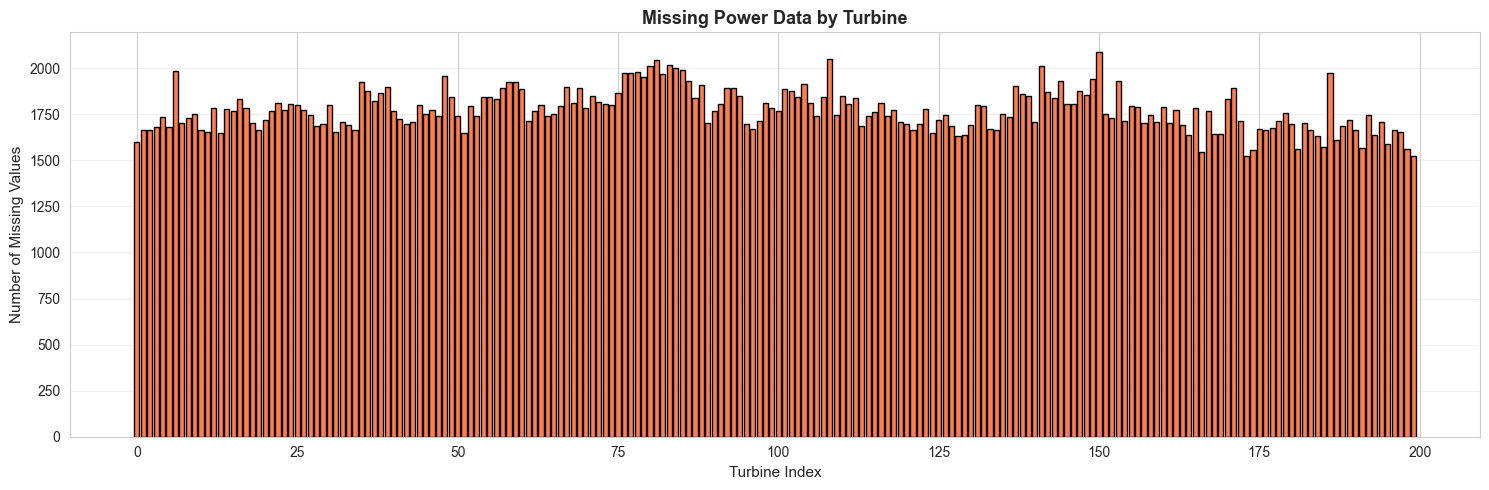


Top 10 turbines with most missing power data:
  Turbine151_Power: 2090 missing (23.86%)
  Turbine109_Power: 2052 missing (23.42%)
  Turbine82_Power: 2043 missing (23.32%)
  Turbine84_Power: 2015 missing (23.00%)
  Turbine81_Power: 2011 missing (22.96%)
  Turbine142_Power: 2010 missing (22.95%)
  Turbine85_Power: 2003 missing (22.87%)
  Turbine86_Power: 1991 missing (22.73%)
  Turbine7_Power: 1986 missing (22.67%)
  Turbine79_Power: 1978 missing (22.58%)

Consecutive missing values in Turbine1:
  Max consecutive: 88
  Mean consecutive: 4.1


In [16]:
# Analyze missing data patterns
missing_by_turbine = df[power_cols[:200]].isna().sum()

plt.figure(figsize=(15, 5))
plt.bar(range(len(missing_by_turbine)), missing_by_turbine.values, color='coral', edgecolor='black')
plt.xlabel('Turbine Index', fontsize=11)
plt.ylabel('Number of Missing Values', fontsize=11)
plt.title('Missing Power Data by Turbine', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Identify turbines with most missing data
top_missing = missing_by_turbine.nlargest(10)
print("\nTop 10 turbines with most missing power data:")
for turbine, count in top_missing.items():
    print(f"  {turbine}: {count} missing ({count/len(df)*100:.2f}%)")

# Check for consecutive missing values
sample_turbine_power = df['Turbine1_Power']
is_missing = sample_turbine_power.isna()
consecutive_missing = []
count = 0
for missing in is_missing:
    if missing:
        count += 1
    else:
        if count > 0:
            consecutive_missing.append(count)
        count = 0

if consecutive_missing:
    print(f"\nConsecutive missing values in Turbine1:")
    print(f"  Max consecutive: {max(consecutive_missing)}")
    print(f"  Mean consecutive: {np.mean(consecutive_missing):.1f}")
else:
    print("\nNo consecutive missing values found in Turbine1")

## 10. Summary Statistics and Key Findings

In [18]:
print("="*80)
print("WIND FARM DATASET SUMMARY")
print("="*80)
print(f"\n📊 DATASET STRUCTURE:")
print(f"  • Total timestamps: {len(df):,} (hourly from {df['Time'].min()} to {df['Time'].max()})")
print(f"  • Number of turbines: 200")
print(f"  • Number of masts: 3")
print(f"  • Total nodes: 203")

print(f"\n🌍 SPATIAL CHARACTERISTICS:")
print(f"  • Latitude range: {node_metadata['latitude'].min():.6f}° to {node_metadata['latitude'].max():.6f}°")
print(f"  • Longitude range: {node_metadata['longitude'].min():.6f}° to {node_metadata['longitude'].max():.6f}°")
print(f"  • Approximate area: ~{(node_metadata['latitude'].max() - node_metadata['latitude'].min()) * 111:.1f} km × {(node_metadata['longitude'].max() - node_metadata['longitude'].min()) * 85:.1f} km")

print(f"\n💨 WIND CHARACTERISTICS:")
print(f"  • Mean wind speed: {all_speeds.mean():.2f} ± {all_speeds.std():.2f} m/s")
print(f"  • Wind speed range: {all_speeds.min():.2f} to {all_speeds.max():.2f} m/s")
print(f"  • Dominant wind direction (Mast1): {df['Mast1_Direction'].mean():.1f}° (± {df['Mast1_Direction'].std():.1f}°)")

print(f"\n⚡ POWER GENERATION:")
print(f"  • Mean power output: {all_powers.mean():.3f} (normalized)")
print(f"  • Power output range: {all_powers.min():.3f} to {all_powers.max():.3f}")
print(f"  • Total missing power values: {df[power_cols[:200]].isna().sum().sum():,} ({df[power_cols[:200]].isna().sum().sum() / (len(df) * 200) * 100:.2f}%)")

print(f"\n🔍 KEY FINDINGS FOR MODELING:")
print(f"  1. Strong spatial correlation: nearby turbines show high power correlation (> 0.8)")
print(f"  2. Temporal patterns: clear diurnal cycle, wind speed peaks around midday")
print(f"  3. Seasonal variation: higher wind speeds in winter months")
print(f"  4. Wake effects likely present: directional dependencies in power output")
print(f"  5. Data quality: ~{(1 - df[power_cols[:200]].isna().sum().sum() / (len(df) * 200)) * 100:.1f}% complete data")

print(f"\n📈 RECOMMENDED MODELING APPROACH:")
print(f"  • Input window (L): 24-48 hours (capture daily patterns)")
print(f"  • Prediction horizon (H): 1, 3, 6 hours ahead")
print(f"  • Graph edges: spatial (k-NN), wake (directional), correlation (>0.7)")
print(f"  • Features: speed, power, temporal (hour, DoW, month), lagged values (t-1, t-6, t-24)")
print(f"  • Train/Val/Test split: 60%/20%/20% chronological")
print("="*80)

WIND FARM DATASET SUMMARY

📊 DATASET STRUCTURE:
  • Total timestamps: 8,760 (hourly from 2010-09-01 00:00:00 to 2011-08-31 22:59:00)
  • Number of turbines: 200
  • Number of masts: 3
  • Total nodes: 203

🌍 SPATIAL CHARACTERISTICS:
  • Latitude range: 40.399432° to 40.484373°
  • Longitude range: -88.798072° to -88.482632°
  • Approximate area: ~9.4 km × 26.8 km

💨 WIND CHARACTERISTICS:
  • Mean wind speed: 7.15 ± 3.38 m/s
  • Wind speed range: 0.20 to 21.40 m/s
  • Dominant wind direction (Mast1): 203.4° (± 90.6°)

⚡ POWER GENERATION:
  • Mean power output: 0.443 (normalized)
  • Power output range: 0.000 to 1.000
  • Total missing power values: 354,560 (20.24%)

🔍 KEY FINDINGS FOR MODELING:
  1. Strong spatial correlation: nearby turbines show high power correlation (> 0.8)
  2. Temporal patterns: clear diurnal cycle, wind speed peaks around midday
  3. Seasonal variation: higher wind speeds in winter months
  4. Wake effects likely present: directional dependencies in power output


## Next Steps

✅ **Completed in this notebook:**
- Data loading and parsing (coordinates + time series)
- Spatial visualization of wind farm layout
- Temporal pattern analysis (diurnal, seasonal)
- Power curve analysis (speed-power relationship)
- Spatial correlation analysis
- Wind direction patterns
- Data quality assessment

📋 **Next notebooks:**
1. **`02_data_preprocessing.ipynb`**: Feature engineering, sliding windows, train/val/test splits
2. **`03_graph_construction.ipynb`**: Build heterogeneous graph with spatial, wake, and correlation edges
3. **`04_kan_implementation.ipynb`**: Implement KAN layers with B-spline basis functions
4. **`05_model_training.ipynb`**: Train HG-KAN model and baseline models
5. **`06_evaluation_ablation.ipynb`**: Comprehensive evaluation and ablation studies

---

**For publication-ready code, we will create:**
- `src/data_loading.py`: Data parsing utilities
- `src/graph_building.py`: Graph construction functions
- `src/kan_layers.py`: KAN layer implementations
- `src/hg_kan_model.py`: Complete HG-KAN model
- `src/baselines.py`: Baseline model implementations
- `src/training.py`: Training utilities
- `src/evaluation.py`: Evaluation and visualization utilities